In [1]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
!pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [3]:
%pip install nltk


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install imbalanced-learn


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import re
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings("ignore")
import random
import json

from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import LabelEncoder

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from imblearn.over_sampling import RandomOverSampler
from scipy.sparse import issparse
from pathlib import Path
from pathlib import Path
import json
import pandas as pd

# Download resources 
import nltk
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

True

In [6]:
DATA_DIR = Path("/home/renku/work/analysis-of-corporate-reports-dataset")

json_files = list(DATA_DIR.rglob("*.json"))

records = []

for file in json_files:
    try:
        # แยก metadata จากชื่อไฟล์
        parts = file.stem.split("_")
        
        company_id = parts[0] if len(parts) > 0 else None
        report_type = parts[1] if len(parts) > 1 else None
        year = parts[2] if len(parts) > 2 else None
        accession_no = parts[3] if len(parts) > 3 else None

        # read JSON
        with open(file, "r", encoding="utf-8") as f:
            data = json.load(f)

        # ดึง text จาก JSON
        if isinstance(data, dict):
            text = data.get("text", str(data))
        else:
            text = str(data)

        records.append({
            "company_id": company_id,
            "report_type": report_type,
            "year": year,
            "accession_no": accession_no,
            "filename": file.name,
            "text": text
        })

    except Exception as e:
        print(f"Error reading {file.name}: {e}")

df = pd.DataFrame(records)

In [7]:
# change year to number
df["year"] = pd.to_numeric(df["year"], errors="coerce")

# เพิ่มความยาวของ text
df["text_length"] = df["text"].astype(str).str.len()

print(df.shape)
df.head()

(992, 7)


,company_id,report_type,year,accession_no,filename,text,text_length
0,1001039,10K,2016,0001001039-16-000516,1001039_10K_2016_0001001039-16-000516.json,"{'cik': '1001039', 'company': 'WALT DISNEY CO/...",187429
1,1001039,10K,2017,0001001039-17-000198,1001039_10K_2017_0001001039-17-000198.json,"{'cik': '1001039', 'company': 'WALT DISNEY CO/...",182418
2,1001039,10K,2018,0001001039-18-000187,1001039_10K_2018_0001001039-18-000187.json,"{'cik': '1001039', 'company': 'WALT DISNEY CO/...",202434
3,100885,10K,2016,0000100885-17-000056,100885_10K_2016_0000100885-17-000056.json,"{'cik': '100885', 'company': 'UNION PACIFIC CO...",245001
4,100885,10K,2017,0000100885-18-000048,100885_10K_2017_0000100885-18-000048.json,"{'cik': '100885', 'company': 'UNION PACIFIC CO...",249189


In [8]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

df[["filename", "clean_text"]].head()

,filename,clean_text
0,1001039_10K_2016_0001001039-16-000516.json,cik company walt disney co filing type k filin...
1,1001039_10K_2017_0001001039-17-000198.json,cik company walt disney co filing type k filin...
2,1001039_10K_2018_0001001039-18-000187.json,cik company walt disney co filing type k filin...
3,100885_10K_2016_0000100885-17-000056.json,cik company union pacific corp filing type k f...
4,100885_10K_2017_0000100885-18-000048.json,cik company union pacific corp filing type k f...


In [9]:
#TF-IDF and 2-grams

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(2, 2),      # 2-grams only
    max_features=1000
)

X_tfidf_2gram = tfidf_vectorizer.fit_transform(df["clean_text"])

tfidf_2gram_df = pd.DataFrame(
    X_tfidf_2gram.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

tfidf_2gram_df.head()

,accepted accounting,accompanying consolidated,accompanying notes,accordance generally,accordance standards,accounting estimates,accounting firm,accounting guidance,accounting policies,accounting principles,...,wide range,working capital,www sec,year end,year ended,year period,year year,years ended,years period,york mellon
0,0.000000,0.00000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.025392,0.000000,...,0.006185,0.000000,0.013690,0.009127,0.009853,0.000000,0.000000,0.000000,0.000000,0.0
1,0.000000,0.00000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.026258,0.000000,...,0.006396,0.000000,0.014156,0.009438,0.010189,0.000000,0.000000,0.000000,0.000000,0.0
2,0.000000,0.00000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.025493,0.000000,...,0.006210,0.000000,0.013744,0.009163,0.014839,0.005923,0.000000,0.000000,0.000000,0.0
3,0.009328,0.00500,0.023149,0.009423,0.019393,0.0,0.030321,0.0,0.040757,0.027282,...,0.000000,0.030498,0.016277,0.024415,0.017573,0.005260,0.036403,0.072871,0.010598,0.0
4,0.008936,0.00479,0.022178,0.009028,0.018579,0.0,0.037348,0.0,0.034708,0.026137,...,0.000000,0.024349,0.015594,0.019492,0.008418,0.005040,0.054804,0.069813,0.015230,0.0


In [11]:
# TOP 20 (2-grams)

In [12]:
top_2grams = (
    tfidf_2gram_df.mean(axis=0)
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

top_2grams.columns = ["bigram", "avg_tfidf"]

top_2grams

,bigram,avg_tfidf
0,financial statements,0.156133
1,fair value,0.147860
2,consolidated financial,0.106634
3,item item,0.099223
4,ended december,0.090974
5,results operations,0.081394
6,million million,0.074713
7,cash flows,0.072175
8,incorporated reference,0.069853
9,common stock,0.068826


In [ ]:
# Plot the graph bi-grams

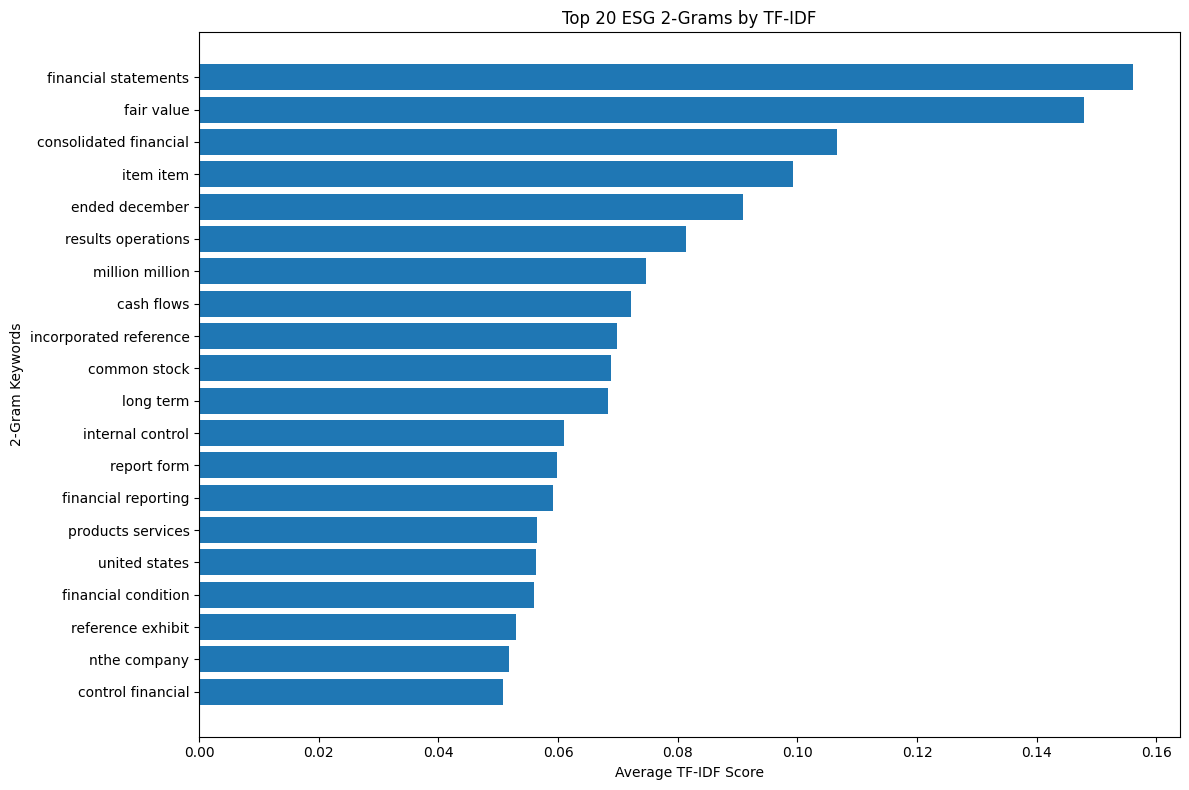

In [13]:
plt.figure(figsize=(12, 8))

plt.barh(
    top_2grams["bigram"],
    top_2grams["avg_tfidf"]
)

plt.xlabel("Average TF-IDF Score")
plt.ylabel("2-Gram Keywords")
plt.title("Top 20 ESG 2-Grams by TF-IDF")

# ให้คำที่สำคัญที่สุดอยู่ด้านบน
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [15]:
# 3-grams 

In [16]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(3,3),    # 3-grams
    max_features=1000
)

X_tfidf_3gram = tfidf_vectorizer.fit_transform(df["clean_text"])

tfidf_3gram_df = pd.DataFrame(
    X_tfidf_3gram.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

print(tfidf_3gram_df.shape)

(992, 1000)


In [17]:
# TOP 20 (3-grams)

In [18]:
top_3grams = (
    tfidf_3gram_df.mean(axis=0)
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

top_3grams.columns = [
    "trigram",
    "avg_tfidf"
]

top_3grams

,trigram,avg_tfidf
0,consolidated financial statements,0.166698
1,control financial reporting,0.084807
2,internal control financial,0.084024
3,year ended december,0.078481
4,incorporated reference exhibit,0.065311
5,years ended december,0.049524
6,consolidated balance sheets,0.045804
7,annual report form,0.045140
8,million million million,0.044177
9,financial statements continued,0.042465


In [ ]:
# Plot 3-grams

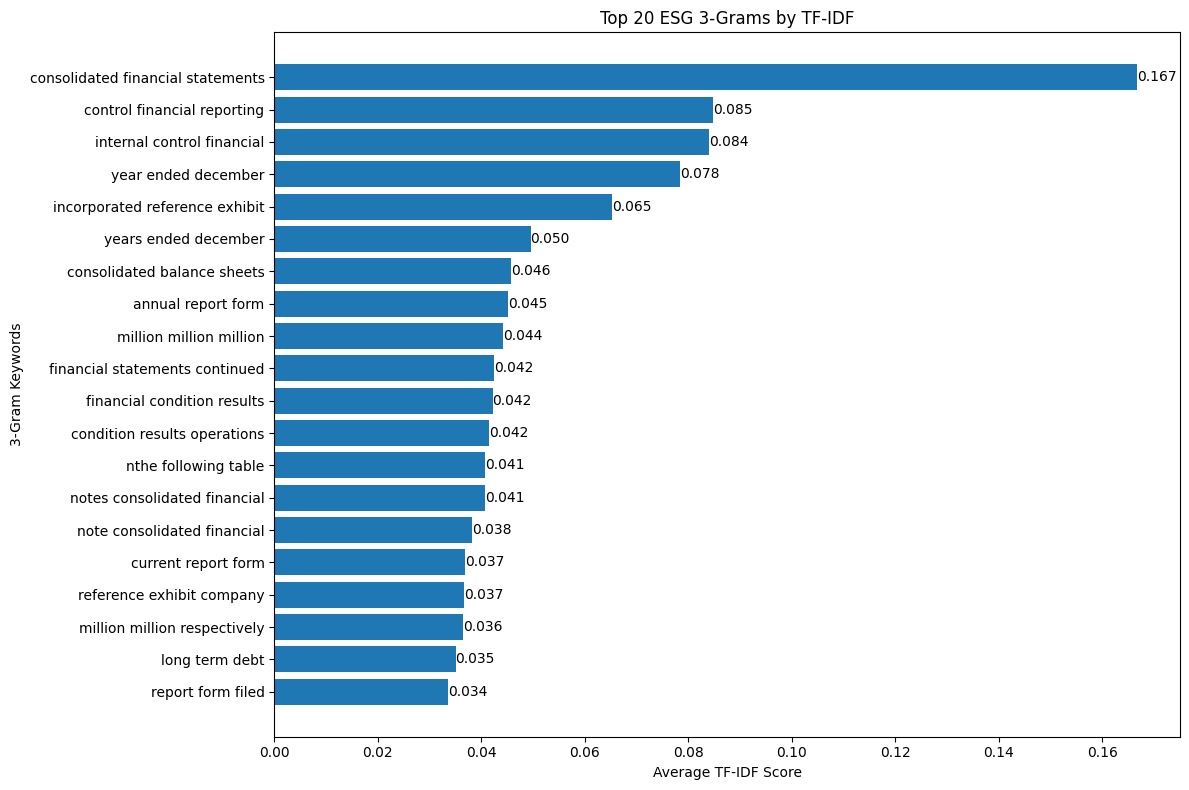

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

bars = plt.barh(
    top_3grams["trigram"],
    top_3grams["avg_tfidf"]
)

plt.xlabel("Average TF-IDF Score")
plt.ylabel("3-Gram Keywords")
plt.title("Top 20 ESG 3-Grams by TF-IDF")

for bar in bars:
    width = bar.get_width()

    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center"
    )

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [24]:
import os
from dotenv import load_dotenv
from openai import OpenAI

# Load .env file
load_dotenv()

# Create client
client_cscs = OpenAI(
    base_url="https://api.swissai.svc.cscs.ch/v1",
    api_key=os.getenv("CSCS_API_KEY")
)

# ESG report text
report_text = """
Paste your ESG report text here.
"""

response = client_cscs.chat.completions.create(
    model="moonshotai/Kimi-K2.5-SDSC",
    messages=[
        {
            "role": "system",
            "content": "You are an expert ESG analyst."
        },
        {
            "role": "user",
            "content": f"""
            Analyze the following ESG report and provide:

            1. Environmental issues
            2. Social issues
            3. Governance issues
            4. ESG risks
            5. ESG opportunities
            6. Executive summary

            Report:
            {report_text}
            """
        }
    ],
    temperature=0.2,
    max_tokens=1500
)

print(response.choices[0].message.content)

OpenAIError: Missing credentials. Please pass an `api_key`, `workload_identity`, `admin_api_key`, or set the `OPENAI_API_KEY` or `OPENAI_ADMIN_KEY` environment variable.

In [ ]:
## by Sector 

In [ ]:
# Topic Modeling 

In [1]:
# =========================
# 1. Import libraries
# =========================

import json
import re
from pathlib import Path

import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF


# =========================
# 2. SIC code → broad sector
# =========================

SIC_TO_SECTOR = {
    "2000": "Consumer Staples", "2080": "Consumer Staples", "2111": "Consumer Staples",
    "2810": "Materials", "2834": "Healthcare", "2836": "Healthcare",
    "2840": "Consumer Staples", "2844": "Consumer Staples", "2911": "Energy",
    "3021": "Consumer Discretionary", "3523": "Industrials", "3531": "Industrials",
    "3570": "Technology", "3571": "Technology", "3576": "Technology",
    "3600": "Industrials", "3663": "Technology", "3674": "Technology",
    "3711": "Consumer Discretionary", "3721": "Industrials", "3724": "Industrials",
    "3730": "Industrials", "3760": "Industrials", "3823": "Healthcare",
    "3829": "Healthcare", "3841": "Healthcare", "3842": "Healthcare",
    "3845": "Healthcare", "4011": "Industrials", "4210": "Industrials",
    "4513": "Industrials", "4812": "Communication Services",
    "4813": "Communication Services", "4841": "Communication Services",
    "4911": "Utilities", "4931": "Utilities", "5211": "Consumer Discretionary",
    "5331": "Consumer Discretionary", "5810": "Consumer Discretionary",
    "5812": "Consumer Discretionary", "5912": "Healthcare",
    "5961": "Consumer Discretionary", "6021": "Financials",
    "6022": "Financials", "6199": "Financials", "6211": "Financials",
    "6311": "Financials", "6324": "Healthcare", "6331": "Financials",
    "6798": "Real Estate", "7370": "Technology", "7372": "Technology",
    "7389": "Financials", "7841": "Communication Services",
    "7990": "Communication Services",
}


# =========================
# 3. ESG dictionary
# =========================

E_KEYWORDS = [
    "environment", "environmental", "climate", "carbon", "emission", "emissions",
    "greenhouse gas", "ghg", "energy", "renewable", "waste", "water",
    "pollution", "recycling", "biodiversity", "sustainability", "net zero"
]

S_KEYWORDS = [
    "employee", "employees", "workforce", "labor", "human capital",
    "health", "safety", "training", "diversity", "inclusion",
    "community", "human rights", "wellbeing", "talent"
]

G_KEYWORDS = [
    "governance", "board", "director", "audit", "ethics", "compliance",
    "anti-corruption", "bribery", "risk management", "internal control",
    "cybersecurity", "data privacy", "shareholder", "transparency"
]

ESG_KEYWORDS = E_KEYWORDS + S_KEYWORDS + G_KEYWORDS


# =========================
# 4. Helper functions
# =========================

def clean_text(text):
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def split_paragraphs(text):
    return re.split(r"\n+|\.\s+", text)


def extract_esg_paragraphs(text):
    paragraphs = split_paragraphs(text)
    
    esg_paras = [
        p for p in paragraphs
        if any(keyword in p.lower() for keyword in ESG_KEYWORDS)
    ]
    
    return " ".join(esg_paras)


def count_keywords(text, keywords):
    text = text.lower()
    return sum(text.count(k.lower()) for k in keywords)


# =========================
# 5. Load 10-K JSON files
# =========================

DATA_DIR = Path("/home/renku/work/analysis-of-corporate-reports-dataset")
files = list(DATA_DIR.glob("*.json"))

records = []

for file in files:
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    company = data.get("company", "")
    sic = str(data.get("sic", ""))
    sector = SIC_TO_SECTOR.get(sic, "Unknown")
    
    full_text = " ".join([
        str(data.get("item_1", "")),
        str(data.get("item_1A", "")),
        str(data.get("item_7", ""))
    ])
    
    esg_text = extract_esg_paragraphs(full_text)
    
    records.append({
        "filename": file.name,
        "company": company,
        "sic": sic,
        "sector": sector,
        "full_text": full_text,
        "esg_text": clean_text(esg_text),
        "full_word_count": len(full_text.split()),
        "esg_word_count": len(esg_text.split()),
        "E_score": count_keywords(esg_text, E_KEYWORDS),
        "S_score": count_keywords(esg_text, S_KEYWORDS),
        "G_score": count_keywords(esg_text, G_KEYWORDS),
    })

df = pd.DataFrame(records)

df["esg_intensity"] = df["esg_word_count"] / df["full_word_count"]
df.head()

,filename,company,sic,sector,full_text,esg_text,full_word_count,esg_word_count,E_score,S_score,G_score,esg_intensity
0,1001039_10K_2016_0001001039-16-000516.json,WALT DISNEY CO/,4841,Communication Services,"ITEM 1. Business\nThe Walt Disney Company, tog...",operating expenses primarily consist of progra...,25041,1947,15,68,12,0.077752
1,1001039_10K_2017_0001001039-17-000198.json,WALT DISNEY CO/,4841,Communication Services,"ITEM 1. Business\nThe Walt Disney Company, tog...",operating expenses primarily consist of progra...,24181,1933,14,66,10,0.079939
2,1001039_10K_2018_0001001039-18-000187.json,WALT DISNEY CO/,4841,Communication Services,"ITEM 1. Business\nThe Walt Disney Company, tog...",operating expenses primarily consist of progra...,27474,1935,14,72,10,0.070430
3,100885_10K_2016_0000100885-17-000056.json,UNION PACIFIC CORP,4011,Industrials,Item 1. Business\n﻿\nGENERAL\n﻿\nUnion Pacific...,union pacific provides value to its roughly cu...,17941,3778,120,118,28,0.210579
4,100885_10K_2017_0000100885-18-000048.json,UNION PACIFIC CORP,4011,Industrials,Item 1. Business\n﻿\nGENERAL\n﻿\nUnion Pacific...,union pacific provides value to its roughly cu...,18541,3817,124,112,29,0.205868


In [2]:
# =========================
# 1. Import libraries
# =========================

import json
import re
from pathlib import Path

import pandas as pd
import numpy as np


# =========================
# 2. File paths
# =========================

DATA_DIR = Path("/home/renku/work/analysis-of-corporate-reports-dataset")

LM_PATH = "/mnt/data/Loughran-McDonald_MasterDictionary_1993-2025.csv"


# =========================
# 3. SIC code → Industry sector
# =========================

SIC_TO_SECTOR = {
    "2000": "Consumer Staples",
    "2080": "Consumer Staples",
    "2111": "Consumer Staples",
    "2810": "Materials",
    "2834": "Healthcare",
    "2836": "Healthcare",
    "2840": "Consumer Staples",
    "2844": "Consumer Staples",
    "2911": "Energy",
    "3021": "Consumer Discretionary",
    "3523": "Industrials",
    "3531": "Industrials",
    "3570": "Technology",
    "3571": "Technology",
    "3576": "Technology",
    "3600": "Industrials",
    "3663": "Technology",
    "3674": "Technology",
    "3711": "Consumer Discretionary",
    "3721": "Industrials",
    "3724": "Industrials",
    "3730": "Industrials",
    "3760": "Industrials",
    "3823": "Healthcare",
    "3829": "Healthcare",
    "3841": "Healthcare",
    "3842": "Healthcare",
    "3845": "Healthcare",
    "4011": "Industrials",
    "4210": "Industrials",
    "4513": "Industrials",
    "4812": "Communication Services",
    "4813": "Communication Services",
    "4841": "Communication Services",
    "4911": "Utilities",
    "4931": "Utilities",
    "5211": "Consumer Discretionary",
    "5331": "Consumer Discretionary",
    "5810": "Consumer Discretionary",
    "5812": "Consumer Discretionary",
    "5912": "Healthcare",
    "5961": "Consumer Discretionary",
    "6021": "Financials",
    "6022": "Financials",
    "6199": "Financials",
    "6211": "Financials",
    "6311": "Financials",
    "6324": "Healthcare",
    "6331": "Financials",
    "6798": "Real Estate",
    "7370": "Technology",
    "7372": "Technology",
    "7389": "Financials",
    "7841": "Communication Services",
    "7990": "Communication Services",
}


# =========================
# 4. Load Loughran-McDonald Dictionary
# =========================

lm = pd.read_csv(LM_PATH)

lm["Word"] = lm["Word"].str.lower()

negative_words = set(lm.loc[lm["Negative"] > 0, "Word"])
positive_words = set(lm.loc[lm["Positive"] > 0, "Word"])
uncertainty_words = set(lm.loc[lm["Uncertainty"] > 0, "Word"])
litigious_words = set(lm.loc[lm["Litigious"] > 0, "Word"])

print(lm.columns)
lm.head()

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/Loughran-McDonald_MasterDictionary_1993-2025.csv'